In this notebook, we will demonstrate how to train scLEMBAS and use it for counterfactual prediction. We will demonstrate this on the [Kang dataset](https://doi.org/10.1038/nbt.4042), which represents a binary perturbation setting (IFNB-stimulated or control unperturbed) for PBMCs.

In [1]:
import json
import os
import urllib.request

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [2]:
seed = 888

# Load Data

As input to scLEMBAS, we need:
- gene expression `g`
- perturbation `X`
- context covariates (here, cell type)
- the signaling network upon which the adjacency matrix `A` is constructed

We also need the response TF activity for training.

In [3]:
cat_col = 'seurat_annotations' # defines cell type metadata in AnnData object
pert_col = 'stim' # defines perturbation metadata in AnnData object

Signaling network:

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

sn_ppis = pd.read_csv('https://zenodo.org/records/21419937/files/Kang_sn_ppis.csv', index_col = 0)
sn_ppis.head()

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped,mode_of_action
0,P0DP23,P48995,CALM1,TRPC1,True,False,True,True,False,True,3,TRIP:11290752;TRIP:11983166;TRIP:12601176,TRIP,1,1,3.0,11290752;11983166;12601176,-1.0
1,P0DP25,P48995,CALM3,TRPC1,True,False,True,True,False,True,3,TRIP:11290752;TRIP:11983166;TRIP:12601176,TRIP,1,1,3.0,11290752;11983166;12601176,-1.0
2,P0DP24,P48995,CALM2,TRPC1,True,False,True,True,False,True,3,TRIP:11290752;TRIP:11983166;TRIP:12601176,TRIP,1,1,3.0,11290752;11983166;12601176,-1.0
3,Q03135,P48995,CAV1,TRPC1,True,True,False,True,True,False,13,DIP:19897728;HPRD:12732636;IntAct:19897728;Lit...,DIP;HPRD;IntAct;Lit-BM-17;TRIP,5,5,8.0,10980191;12732636;14551243;16822931;18430726;1...,1.0
6,Q14571,P48995,ITPR2,TRPC1,True,True,False,True,True,False,13,HPRD:10970773;HPRD:11336651;TRIP:10970773;TRIP...,HPRD;TRIP,2,2,11.0,10970773;11336651;12196544;15121806;16870612;1...,1.0


Expression data:

In [5]:
url = 'https://zenodo.org/records/21419937/files/Kang_expr_scored.h5ad'
urllib.request.urlretrieve(url, 'Kang_expr_scored.h5ad')
adata = sc.read_h5ad('Kang_expr_scored.h5ad')
expr = adata.to_df().copy()
adata

AnnData object with n_obs × n_vars = 13576 × 5000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stim', 'seurat_annotations', 'n_genes', 'condition'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'consensus_estimate', 'consensus_pvals', 'mlm_estimate', 'mlm_pvals', 'ulm_estimate', 'ulm_pvals', 'wsum_estimate'
    layers: 'counts'

TF activity:

In [6]:
url = 'https://zenodo.org/records/21419937/files/Kang_tf_activity.h5ad'
urllib.request.urlretrieve(url, 'Kang_tf_activity.h5ad')
tf_adata = sc.read_h5ad('Kang_tf_activity.h5ad')

tf_adata.obs['condition'] = tf_adata.obs[cat_col].astype(str) + '^' + tf_adata.obs[pert_col].astype(str)
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

tf_adata

View of AnnData object with n_obs × n_vars = 13576 × 336
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stim', 'seurat_annotations', 'n_genes', 'condition', 'TF_clusters'
    uns: 'leiden', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

# Train Model

In [7]:
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

from scLEMBAS import preprocess as pp 
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC

We will train on one split of the 5-fold CV conducted in the manuscript. 

In [8]:
fold = 1
url = 'https://zenodo.org/records/21419937/files/Kang_5foldCV_splits.json'
with urllib.request.urlopen(url) as f:
    all_splits = json.load(f)
    
split = all_splits[str(fold)]

print('The train conditions are: ', *split['train_conds'], sep='')
print()
print('The test conditions are: ', *split['test_conds'], sep='')


The train conditions are: CD4 Naive T^CTRLCD4 Memory T^STIMDC^STIMCD16 Mono^CTRLCD4 Naive T^STIMB Activated^STIMB^CTRLNK^CTRLDC^CTRLCD14 Mono^CTRLT activated^CTRLCD8 T^STIMB^STIMB Activated^CTRLT activated^STIMCD14 Mono^STIM

The test conditions are: CD16 Mono^STIMNK^STIMCD4 Memory T^CTRLCD8 T^CTRL


Let's set up the hyperparameters for training:

In [9]:
def generate_lr_params(n_epochs, max_lr, lr_scaling_factor=10, lr_decay=0.75, 
                       n_adversarial_start = 200, 
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    Parameters:
        - n_epochs: total training epochs
        - max_lr: peak learning rate
        - lr_scaling_factor: factor to determine min LR
        - lr_decay: gamma decay per restart
        - n_adversarial_start: epoch when adversarial training begins
        - n_discriminator_train: frequency of discriminator training relative to generator
        - n_restarts: desired number of cosine peaks (n_restarts)
        - role: 'scl' or discriminator' or 'generator'

    Returns:
        Dict of scheduler parameters
    """

    total_active_epochs = n_epochs
    n_discriminator_train_ = 1
    if role in ['discriminator', 'generator']:
        total_active_epochs = n_epochs - n_adversarial_start
        if role == 'generator':
            n_discriminator_train_ = n_discriminator_train
            
    n_restarts = 4 if total_active_epochs // n_discriminator_train_ > 500 else 2


    T_0 = max(1, (total_active_epochs // n_discriminator_train_) // n_restarts)
    warmup_epochs = max(1, (total_active_epochs // n_discriminator_train_) // 10)

#     if reset_state:
#         if total_active_epochs // n_discriminator_train_ > 400:
#             n_optimizer_resets = 2
#         elif total_active_epochs // n_discriminator_train_ < 100:
#             n_optimizer_resets = 0
#         else:
#             n_optimizer_resets = 1
#     else:
    n_optimizer_resets = 0
        
    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,  
        'n_optimizer_resets': n_optimizer_resets,  
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }

def generate_discriminator_params(n_epochs, max_lr, discriminator_penalty_weight, 
                                  discriminator_dropout_rate,
                                  lr_scaling_factor,
                                  lr_decay):
    general_params = generate_lr_params(n_epochs, 
                                        max_lr, 
                                        lr_scaling_factor = lr_scaling_factor, 
                                        lr_decay = lr_decay,
                                       role = 'discriminator')
    
    keys_to_keep = ['maximum_learning_rate', 'minimum_learning_rate', 'lr_restart_epoch', 
                   'warmup_epochs', 'lr_decay', 'n_optimizer_resets']
    discriminator_params = {'batch_momentum': 0,
                            'layer_norm': False,
                            'spectral_norm': False,
                            'dropout_rate': discriminator_dropout_rate,
                            'activation_fn': nn.LeakyReLU,
                            'n_hidden_nodes': [768, 512, 256],
                            'lr_restart_factor': 1,
                            'optimizer': torch.optim.Adam,
                            'discriminator_lambda_L2': 1e-3,
                            'discriminator_penalty_weight': discriminator_penalty_weight, 
                            'bionet_activation': False,
                           'smooth_labels': True, 
                           'epsilon_smoothing': 0.1}
    discriminator_params = {**discriminator_params, 
                           **{k:v for k,v in general_params.items() if k in keys_to_keep}}
    
    return discriminator_params

In [10]:



# ------------------------------------- BATCHES -------------------------------------

# batches

n_train_cells = len(split['train_barcodes'])
n_test_cells = len(split['test_barcodes'])

n_batches = 22
batch_params = {
    'train_batch_size': int(np.round(n_train_cells/n_batches)), 
    'test_batch_size': int(np.round(n_test_cells/n_batches)), 
    'validation_batch_size': np.nan, 
    'drop_last_batch': True
}

# ------------------------------------- PRESETS -------------------------------------
# direct into init but used in other parts
projection_amplitude_out = 1

# lr presets
max_epochs = 600
n_adversarial_start = 200
lr_scaling_factor = 10
lr_decay = 0.9

# ------------------------------------- BULK LEMBAS -------------------------------------
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5,  
                          'subset_n_spectral': 5, 
                         'track_spectral_radius': True} 
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True

}

prediction_loss_fn = torch.nn.MSELoss(reduction='mean')
lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = 2e-3, 
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay, 
    role = 'scl'
)

# ------------------------------------- REGULARIZERS -------------------------------------
bionet_params['cat_max_norm'] = 100

regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False

    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': 0, #1e-7, 
    'uniform_min': 0, #-1/projection_amplitude_out,
    'uniform_max': 1, #1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0

    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,

    'spectral_loss_factor': 0,


    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': 1e-4,  # allow for generalization (not collapsing on perturbation)
    'cat_bias_lambda_L1': 0, # using cat max norm
}

contrastive_loss_params = {
    'methods': [], 
    'lambda_scalers': [], 
    'understimate_only': np.nan, # only for _bulk_actual
    'min_percentile': np.nan, # only for _sc
    'triplet_margin_frac': np.nan, # for sc only
}


cat_pert_params = {
    'regularization_scaler': 100, 
    'method': 'orthogonality', 
    'per_label': False, 
    'include_adjacency': False, 
    'temperature': 0.1
                      }

# aggregate
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = 100


# ------------------------------------- VAE -------------------------------------
n_layers_vae = 2
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])


vae_mod_params = {'vae_batch_momentum': 0.01, 
              'vae_layer_norm': False, 
              'vae_dropout_rate': 0.7,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4, 
                 }

vae_params = {'prior_mu': 0,
       'prior_sigma': 1,
       'lambda_l2': 1e-5,
       'scaling_KL': 1e-3, 
       'optimizer': torch.optim.Adam}
vae_lr_params = generate_lr_params(
        n_epochs = max_epochs, 
        max_lr = 5e-4,
        lr_scaling_factor = lr_scaling_factor, 
        lr_decay = lr_decay,
        role = 'discriminator'
    ) 

vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']

# ------------------------------------- DISCRIMINATORS -------------------------------------
cat_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = max_epochs - n_adversarial_start,
    min_penalty_weight = 0.1,
    max_penalty_weight = 12,
    a = 1,
    b = 2, 
    curve_type = 'power')

pert_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = max_epochs - n_adversarial_start,
    min_penalty_weight = 0.1,
    max_penalty_weight = 8,
    a = 1,
    b = 3.5, 
    curve_type = 'power')

n_cat_discriminator_train = 5
n_pert_discriminator_train = 5




cat_discriminator_params = generate_discriminator_params(
    n_epochs = max_epochs,                              
    max_lr = 1e-3,                                          
    discriminator_dropout_rate = 0.1,                                                 
    discriminator_penalty_weight = cat_discriminator_penalty_weight,                                               
    lr_scaling_factor = lr_scaling_factor, lr_decay = lr_decay)
pert_discriminator_params = generate_discriminator_params(
    n_epochs = max_epochs,                        
    max_lr = 1e-3,                                                    
    discriminator_dropout_rate = 0.1,                                                
    discriminator_penalty_weight = pert_discriminator_penalty_weight,                                                    
    lr_scaling_factor = lr_scaling_factor, lr_decay = lr_decay)




Initialize the model:

In [11]:
# ------------------------------------- INITIALIZATION -------------------------------------
# input stimulation
X_in = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1'])

y_out = tf_adata.to_df().copy()

mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = y_out, 
    rand_y_features = False, # creates baseline random models
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = [cat_col],
    projection_amplitude_in = 10, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius




Initialize and run the trainer:

In [12]:
if not os.path.isfile('./Kang_model.pt'):
    trainer = TrainSC(
        mod = mod,
        prediction_optimizer = torch.optim.Adam,
        prediction_loss_fn = prediction_loss_fn, 
        per_condition_loss = True,
        n_adversarial_start = n_adversarial_start, 
        n_cat_discriminator_train = n_cat_discriminator_train,
        n_pert_discriminator_train = n_pert_discriminator_train,
        gradient_ascent = True,
        cat_discriminator_params = cat_discriminator_params,
        pert_discriminator_params = pert_discriminator_params,
        vae_params = vae_params,
        hyper_params = training_params,
        contrastive_loss_params = contrastive_loss_params,
        cat_pert_params = cat_pert_params,
        train_split = {'train': split['train_barcodes'], 'test': split['test_barcodes'], 'validation': None}, 
        train_seed = seed, 
        n_track_test = 20,
        n_track_validation = None, 
        n_eval_cells = np.nan, 
        n_eval_bootstrap = np.nan
    )
    mod = trainer.train_model(verbose = False)
    torch.save(mod.state_dict(), 'Kang_model.pt')
else:
    mod_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    mod.to(mod_device)
    state_dict = torch.load(
        'Kang_model.pt',
        map_location=mod_device,
        weights_only=True,
    )

    mod.load_state_dict(state_dict)

# Predict

In [13]:
from scLEMBAS.predict import get_prediction

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_test/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


Note, in Kang specifically, we always  used the corresponding stimulation condition of a given cell type for the counterfactual. So if the cell type in test was stimulated, it was predicted from the unstimulated cell type in training, and vice versa. In multi-perturbation setting, we typically only predicted from unstimulated cells to a specific cell stimulation. 

In [14]:
ctrl_pert = 'CTRL'
rev_stim = {'IFNB1': 'CTRL', 'CTRL': 'IFNB1'}

# formatting
tf_adata.obs[pert_col] = tf_adata.obs[pert_col].replace('STIM', 'IFNB1')
tf_adata.obs['condition'] = tf_adata.obs[cat_col].astype(str) + '^' + tf_adata.obs[pert_col].astype(str)


/tmp/ipykernel_3361050/3203878590.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tf_adata.obs[pert_col] = tf_adata.obs[pert_col].replace('STIM', 'IFNB1')


In [15]:
test_conds = [i.replace('STIM', 'IFNB1') for i  in split['test_conds']]
train_barcodes = split['train_barcodes']
test_barcodes = split['test_barcodes']

In [16]:
# get the control cells (from which counterfactual was predicted)
ctrl_conds = sorted(set([tc.split('^')[0] + '^' + rev_stim[tc.split('^')[1]] for tc in test_conds]))
ctrl_mask = tf_adata.obs.loc[train_barcodes, 'condition'].isin(ctrl_conds).values
ctrl_cells = list(np.array(train_barcodes)[ctrl_mask])


In [17]:
print('The test conditions ', ', '.join(test_conds), ' will be predicted from ', ', '.join(ctrl_conds), ' respectively', sep='')



The test conditions CD16 Mono^IFNB1, NK^IFNB1, CD4 Memory T^CTRL, CD8 T^CTRL will be predicted from CD16 Mono^CTRL, CD4 Memory T^IFNB1, CD8 T^IFNB1, NK^CTRL respectively


In [18]:
tf_adata_predicted = get_prediction(
    mod = mod,
    train_cells = train_barcodes,
    test_cells = test_barcodes, 
    tf_adata = tf_adata,
    cat_col = cat_col,
    pert_col = pert_col,
    ctrl_pert = ctrl_pert, 
    counterfactual = 'perturbation',
    cat_counterfactual_map = None,
    remove_type = 'none', # do not ablate any model components
    return_bias = False, # return the full model prediciton, not just the bias
    max_cells = int(5e3), # batches for memory
    return_full = False, # return just the predicted TF features after ProjectOutput, rather than the RNN outpuut
    stim_label_map = {'IFNB1': 'IFNB1', 'CTRL': 'CTRL'}, 
)
assert tf_adata_predicted.n_vars == tf_adata.n_vars, 'Incorrect features are getting predicted'

Set up inputs for prediction


100%|████████████████████████████████████████████| 4/4 [00:00<00:00,  6.41it/s]


Get the predictions


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_test/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


`condition` annotates the predicted condition, `counterfactual_condition` annotates the counterfactual condition from which `condition` was predicted (gene expression vector)

In [19]:
tf_adata_predicted.obs.head()

,seurat_annotations,stim,condition,counterfactual_condition,vae_input_barcodes
0,CD16 Mono,IFNB1,CD16 Mono^IFNB1,CD16 Mono^CTRL,AAACGGCTTACTCT.1
1,CD16 Mono,IFNB1,CD16 Mono^IFNB1,CD16 Mono^CTRL,AAACTTGACTGGAT.1
2,CD16 Mono,IFNB1,CD16 Mono^IFNB1,CD16 Mono^CTRL,AAAGCAGATGCAAC.1
3,CD16 Mono,IFNB1,CD16 Mono^IFNB1,CD16 Mono^CTRL,AAAGCCTGGGATTC.1
4,CD16 Mono,IFNB1,CD16 Mono^IFNB1,CD16 Mono^CTRL,AAAGGCCTAAACGA.1


# Quantitate and Visualize

In [20]:
from scLEMBAS.metrics import distances
from scLEMBAS import latent_separation as ls


We can, for example, calculate the per-condition Earth Mover's distance between predicted and actual data:

In [21]:
distances.get_EMD_loss(tf_adata, tf_adata_predicted)

{'CD16 Mono^IFNB1': 46.874481201171875,
 'CD4 Memory T^CTRL': 82.0328369140625,
 'CD8 T^CTRL': 85.4541015625,
 'NK^IFNB1': 80.10321044921875,
 'Mean EMD Loss': 73.61615753173828}

We can also visualize predictions in PCA spcae compared to actual data. 

First, we will fit a PC model on the actual data subsetted to the test conditions:

In [22]:
test_mask = tf_adata.obs.condition.isin(test_conds)
tf_adata_actual = tf_adata[test_mask].copy()

In [23]:
tf_adata_actual, _, cv_df_pca_global  = ls.pc_pipeline(
    adata = tf_adata_actual,
    pert_ids = tf_adata_actual.obs[pert_col].unique(), # don't subset
    cat_ids = tf_adata_actual.obs[cat_col].unique(), # don't subset
    n_components = None, # estimate out of 50 using automated elbow
    pert_col = pert_col,
    cat_col = cat_col,
    get_hvgs = False, # tf activity doesn't use HVGs 
    run_umap = False,
    covariate_associations = None, 
    per_component_association = False, # won't be used since `covariate_associations` is None
    global_component_association = True, # won't be used since `covariate_associations` is None
    file_prefix = None, # does not store any rersults
    verbose = True,
    n_cores = 1,
    seed = seed,
    embkwrgs = {
        'cluster_data': False, 
        'n_neighbors': 15, # unused since `cluster_data` set to False
        'resolution': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0], # unused since `cluster_data` set to False
        'cluster_col_name': 'TF_clusters', # unused since `cluster_data` set to False
        'nmi_label': 'condition', # unused since `cluster_data` set to False
        
        'scale': False, # TF activity is z-scored
        'pcakwrgs': {
            'use_highly_variable': False, # TF activity is already a smoothing across features
            'zero_center': False  #TF activity is z-scored
        }    
    }
)

Run dimensionality reductions


Verify the automated elbow dimensionality selection:

The elbow was automatically identified at PC 12


''

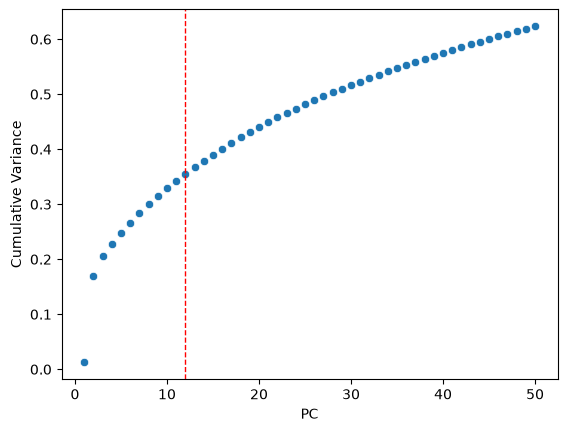

In [24]:
fig, ax = plt.subplots()
sns.scatterplot(
    y=np.cumsum(tf_adata_actual.uns['pca']['variance_ratio']),
    x=range(1, tf_adata_actual.uns['pca']['variance_ratio'].shape[0] + 1),
    ax=ax
)
ax.set_ylabel('Cumulative Variance')
ax.set_xlabel('PC')

n_pcs = tf_adata_actual.uns['pca']['pca_rank']
ax.axvline(x=n_pcs, color='red', linestyle='--', linewidth=1)

print('The elbow was automatically identified at PC {}'.format(n_pcs))
;

Now, we can project the predicted data into the identified PC space:

In [25]:
X_pred = ls.project_to_pca(X_new = tf_adata_predicted.X, adata = tf_adata_actual)
tf_adata_predicted.obsm['X_pca'] = X_pred

Finally, we can visualize these two side by side. We will skip PC1 as this captures the mean TF activity (while we chose not to zero-center due to these being 'consensus' scores, there is still a bias in the activity distribution). 

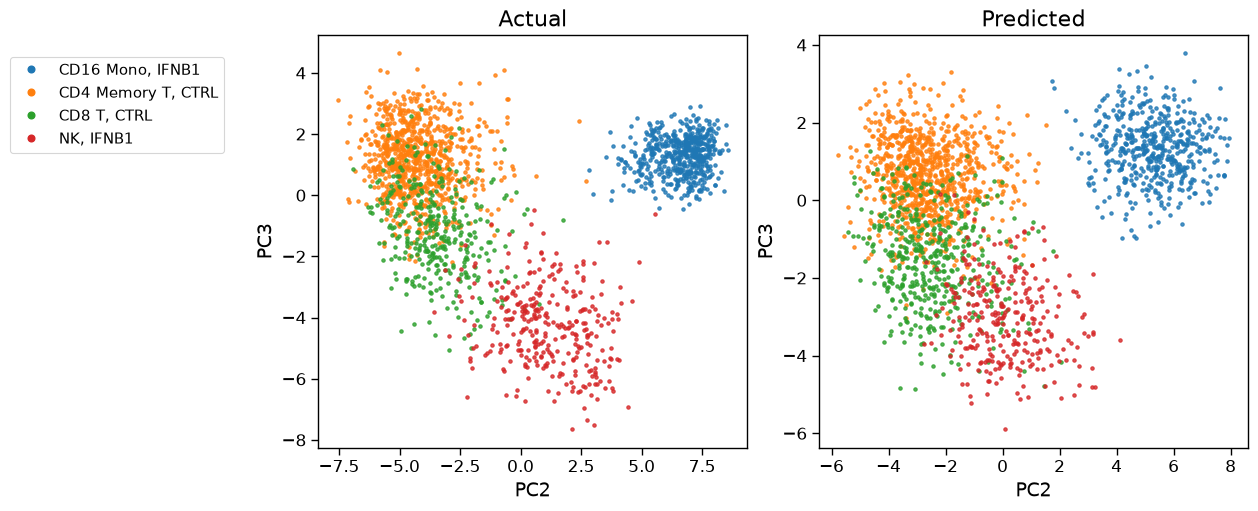

In [26]:
# shared color mapping so both panels use the same colors
conditions = sorted(tf_adata_actual.obs["condition"].astype(str).unique())
palette = dict(zip(conditions, sns.color_palette(n_colors=len(conditions))))

with sns.plotting_context(
    "paper", font_scale=1.1,
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 11,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    },
):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), constrained_layout=True)

    for ax, adata, title in zip(
        axes, [tf_adata_actual, tf_adata_predicted], ["Actual", "Predicted"]
    ):
        X = adata.obsm["X_pca"]
        groups = adata.obs["condition"].astype(str).values
        for condition in conditions:
            mask = groups == condition
            ax.scatter(X[mask, 1], X[mask, 2], color=palette[condition], s=6, alpha=0.8)
        ax.set_title(title)
        ax.set_xlabel("PC2")
        ax.set_ylabel("PC3")

    # one legend for the whole figure, placed to the left
    handles = [
        Line2D([0], [0], marker="o", linestyle="none", color=palette[c])
        for c in conditions
    ]
    labels = [c.replace("^", ", ") for c in conditions]
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(-0.25, 0.8))

    plt.show()